# StatCast Minor Leagues Model
This notebook will demonstrate that StatCast data is a better predictor for minor league players in the major leagues compared to traditional data.

## Read Data

In [1]:
from typing import List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
)

In [2]:
# Read data
df_1 = pd.read_csv("data/statcast-minor-leagues/savant_data_2025.csv")
df_2 = pd.read_csv("data/statcast-minor-leagues/savant_data_2024.csv")
df_3 = pd.read_csv("data/statcast-minor-leagues/savant_data_2023.csv")

df_minor_leagues = pd.concat([df_1, df_2, df_3])

# Rename columns
df_minor_leagues.rename(
    {"player_id": "StatCast_ID", "player_name": "Name"},
    axis=1,
    inplace=True,
)

# Drop columns
df_minor_leagues.drop(
    [
        "pitches",
        "total_pitches",
        "pitch_percent",
        "spin_rate",
        "velocity",
        "eff_min_vel",
        "release_extension",
        "pos3_int_start_distance",
        "pos4_int_start_distance",
        "pos5_int_start_distance",
        "pos6_int_start_distance",
        "pos7_int_start_distance",
        "pos8_int_start_distance",
        "pos9_int_start_distance",
        "pitcher_run_exp",
        "bat_speed",
        "swing_length",
        "api_break_z_with_gravity",
        "api_break_z_induced",
        "api_break_x_arm",
        "api_break_x_batter_in",
        "release_pos_z",
        "release_pos_x",
        "plate_x",
        "plate_z",
        "pitcher_run_value_per_100",
        "arm_angle",
        "attack_angle",
        "attack_direction",
        "swing_path_tilt",
        "rate_ideal_attack_angle",
        "intercept_ball_minus_batter_pos_x_inches",
        "intercept_ball_minus_batter_pos_y_inches",
    ],
    axis=1,
    inplace=True,
)

# Drop null values (since <50 null values per columns)
df_minor_leagues.dropna(inplace=True)


# Fix name format from "last_name, first_name" to first name last name"
def fix_name(name: str) -> str:
    last, first = [part.strip() for part in name.split(",", 1)]
    return f"{first} {last}"


df_minor_leagues["Name"] = df_minor_leagues["Name"].apply(fix_name)

# Move Name to the be the first column
col_data = df_minor_leagues.pop("Name")
df_minor_leagues.insert(0, "Name", col_data)

# Display
df_minor_leagues

,Name,StatCast_ID,year,ba,iso,babip,slg,woba,xwoba,xba,...,obp,barrels_total,batter_run_value_per_100,xobp,xslg,xbadiff,xobpdiff,xslgdiff,wobadiff,swing_miss_percent
0,Samad Taylor,669392,2025,0.282,0.172,0.334,0.454,0.359,0.302,0.229,...,0.370,15.0,1.033460,0.326,0.342,0.053,0.044,0.112,0.057,22.6
1,Jonathon Long,675085,2025,0.304,0.173,0.357,0.478,0.384,0.373,0.274,...,0.403,40.0,1.551608,0.381,0.471,0.030,0.022,0.007,0.011,22.2
2,Ryan Ward,669899,2025,0.290,0.267,0.312,0.557,0.397,0.362,0.270,...,0.377,50.0,2.045763,0.361,0.467,0.020,0.016,0.090,0.035,21.6
3,Clay Dungan,687867,2025,0.270,0.176,0.340,0.446,0.353,0.309,0.234,...,0.365,18.0,0.795609,0.336,0.348,0.036,0.029,0.098,0.044,25.0
4,Yonathan Perlaza,666632,2025,0.302,0.205,0.360,0.507,0.384,0.349,0.272,...,0.386,30.0,1.225263,0.360,0.435,0.030,0.026,0.072,0.035,30.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,Michael Mantecón,685722,2023,0.000,0.000,0.000,0.000,0.000,0.089,0.096,...,0.000,0.0,-12.900000,0.096,0.112,-0.096,-0.096,-0.112,-0.089,40.0
1198,Seth Brown,664913,2023,0.500,0.000,1.000,0.500,0.441,0.246,0.262,...,0.500,0.0,2.014286,0.262,0.299,0.238,0.238,0.201,0.195,66.7
1199,Edinson Duran,702750,2023,0.000,0.000,0.000,0.000,0.000,0.067,0.074,...,0.000,0.0,-10.466667,0.074,0.077,-0.074,-0.074,-0.077,-0.067,33.3
1202,Erison Placencia,691758,2023,0.000,0.000,0.000,0.000,0.000,0.145,0.146,...,0.000,0.0,-7.040000,0.146,0.180,-0.146,-0.146,-0.180,-0.145,33.3


## ID Mapping to find Major League Counterpart

In [3]:
# Read data
mlb_career_stats_df = pd.read_csv("data/mlb-career-stats.csv")

# Inner join
mapped_players = df_minor_leagues.merge(
    mlb_career_stats_df, how="inner", left_on="StatCast_ID", right_on="StatCast_ID"
)

# Drop columns
mapped_players.drop("Name_y", axis=1, inplace=True)

# Rename columns
mapped_players.rename(
    columns={
        "Name_x": "Name",
        "ba": "minor_BA",
        "iso": "minor_ISO",
        "babip": "minor_BABIP",
        "slg": "minor_SLG",
        "woba": "minor_wOBA",
        "xwoba": "minor_xwOBA",
        "xba": "minor_xBA",
        "hits": "minor_hits",
        "abs": "minor_AB",
        "launch_speed": "minor_launch_speed",
        "launch_angle": "minor_launch_angle",
        "effective_speed": "minor_effective_speed",
        "whiffs": "minor_whiffs",
        "swings": "minor_swings",
        "takes": "minor_takes",
        "run_exp": "minor_run_exp",
        "pa": "minor_PA",
        "bip": "minor_BIP",
        "singles": "minor_singles",
        "doubles": "minor_doubles",
        "triples": "minor_triples",
        "hrs": "minor_HR",
        "so": "minor_SO",
        "k_percent": "minor_K_percent",
        "bb": "minor_BB",
        "bb_percent": "minor_BB_percent",
        "hyper_speed": "minor_hyper_speed",
        "bbdist": "minor_bbdist",
        "hardhit_percent": "minor_hardhit_percent",
        "barrels_per_bbe_percent": "minor_barrels_per_bbe_percent",
        "barrels_per_pa_percent": "minor_barrels_per_pa_percent",
        "obp": "minor_OBP",
        "barrels_total": "minor_barrels_total",
        "batter_run_value_per_100": "minor_batter_run_value_per_100",
        "xobp": "minor_xOBP",
        "xslg": "minor_xSLG",
        "xbadiff": "minor_xBA_diff",
        "xobpdiff": "minor_xOBP_diff",
        "xslgdiff": "minor_xSLG_diff",
        "wobadiff": "minor_wOBA_diff",
        "swing_miss_percent": "minor_swing_miss_percent",
        "AB": "major_AB",
        "PA": "major_PA",
        "1B": "major_1B",
        "2B": "major_2B",
        "3B": "major_3B",
        "HR": "major_HR",
        "K": "major_K",
        "BB": "major_BB",
        "K%": "major_K_percent",
        "BB%": "major_BB_percent",
        "BA": "major_BA",
        "SLG": "major_SLG",
        "OBP": "major_OBP",
        "OPS": "major_OPS",
        "ISO": "major_ISO",
        "BABIP": "major_BABIP",
        "CS": "major_CS",
        "SB": "major_SB",
        "HBP": "major_HBP",
        "IBB": "major_IBB",
        "SF": "major_SF",
        "Speed": "major_Speed",
        "wOBA": "major_wOBA",
        "wRAA": "major_wRAA",
        "wRC": "major_wRC",
    },
    inplace=True,
)

# Sort
mapped_players = mapped_players.sort_values(
    by=["Name", "year"], ascending=True
).reset_index(drop=True)

mapped_players

,Name,StatCast_ID,year,minor_BA,minor_ISO,minor_BABIP,minor_SLG,minor_wOBA,minor_xwOBA,minor_xBA,...,major_BABIP,major_CS,major_SB,major_HBP,major_IBB,major_SF,major_Speed,major_wOBA,major_wRAA,major_wRC
0,AJ Pollock,572041,2023,0.167,0.167,0.333,0.333,0.277,0.268,0.206,...,0.297,21,95,31,9,30,28.311111,0.339,63.897106,453.423106
1,Aaron Hicks,543305,2023,0.125,0.000,0.200,0.125,0.110,0.167,0.183,...,0.273,20,58,15,9,24,27.720000,0.321,13.240171,382.365171
2,Aaron Schunk,668845,2023,0.290,0.170,0.364,0.461,0.347,0.295,0.249,...,0.313,1,0,0,1,0,27.650000,0.237,-7.859940,7.533060
3,Aaron Schunk,668845,2024,0.291,0.178,0.336,0.469,0.348,0.288,0.233,...,0.313,1,0,0,1,0,27.650000,0.237,-7.859940,7.533060
4,Aaron Schunk,668845,2025,0.291,0.188,0.333,0.478,0.356,0.312,0.257,...,0.313,1,0,0,1,0,27.650000,0.237,-7.859940,7.533060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725,Zack Short,670097,2024,0.216,0.057,0.311,0.273,0.296,0.308,0.210,...,0.220,2,10,2,1,9,27.650000,0.255,-29.227632,42.344368
1726,Zack Short,670097,2025,0.201,0.164,0.243,0.365,0.318,0.318,0.198,...,0.220,2,10,2,1,9,27.650000,0.255,-29.227632,42.344368
1727,Óscar Mercado,640458,2023,0.299,0.224,0.348,0.523,0.378,0.313,0.247,...,0.270,8,29,8,0,6,28.580000,0.291,-21.241482,98.409518
1728,Óscar Mercado,640458,2024,0.219,0.184,0.229,0.403,0.307,0.296,0.232,...,0.270,8,29,8,0,6,28.580000,0.291,-21.241482,98.409518


## Model Building (and K-Fold Cross Validation)
Similar to before, test different models to predict major league production in wOBA, wRAA, and wRC. These models are:
* Linear Regression
* Decision Trees
* Random Forest
* XGBoost

Apply K-Fold Cross Validation to ensure robustness.

In [4]:
def evaluate_models_cv(models, X, y, cv_splits=5):
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    results = []
    for name, model in models.items():
        mae = -cross_val_score(
            model,
            X,
            y,
            cv=kf,
            scoring=make_scorer(mean_absolute_error, greater_is_better=False),
        )
        mse = -cross_val_score(
            model,
            X,
            y,
            cv=kf,
            scoring=make_scorer(mean_squared_error, greater_is_better=False),
        )
        rmse = np.sqrt(mse)

        results.append(
            {"Model": name, "MAE": mae.mean(), "MSE": mse.mean(), "RMSE": rmse.mean()}
        )

    return pd.DataFrame(results)

## Predictions

In [5]:
# Define X
X = mapped_players.drop(
    [
        "Name",
        "StatCast_ID",
        "year",
        "major_AB",
        "major_PA",
        "major_1B",
        "major_2B",
        "major_3B",
        "major_HR",
        "major_K",
        "major_BB",
        "major_K_percent",
        "major_BB_percent",
        "major_BA",
        "major_SLG",
        "major_OBP",
        "major_OPS",
        "major_ISO",
        "major_BABIP",
        "major_CS",
        "major_SB",
        "major_HBP",
        "major_IBB",
        "major_SF",
        "major_Speed",
        "major_wOBA",
        "major_wRAA",
        "major_wRC",
    ],
    axis=1,
)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
}

### wOBA

In [6]:
# Define y for wOBA
y = mapped_players["major_wOBA"]
results_df = evaluate_models_cv(models, X, y, cv_splits=10)
results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,0.034914,0.002466,0.049581
1,Decision Tree,0.051880,0.005165,0.071742
2,Random Forest,0.035456,0.002464,0.049577
3,XGBoost,0.038145,0.002736,0.052250


### wRAA

In [7]:
# Define y for wRAA
y = mapped_players["major_wRAA"]
results_df = evaluate_models_cv(models, X, y, cv_splits=10)
results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,16.219263,869.050750,29.059553
1,Decision Tree,22.672208,1715.362265,40.919964
2,Random Forest,16.512057,865.956100,29.049354
3,XGBoost,17.616991,930.937653,30.215354


### wRC

In [8]:
# Define y for wRC
y = mapped_players["major_wRC"]
results_df = evaluate_models_cv(models, X, y, cv_splits=10)
results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,89.427032,16786.709953,128.961097
1,Decision Tree,113.407347,31971.206072,178.501277
2,Random Forest,82.516694,14935.052609,121.805186
3,XGBoost,85.330944,16862.378974,129.574097


## Plots

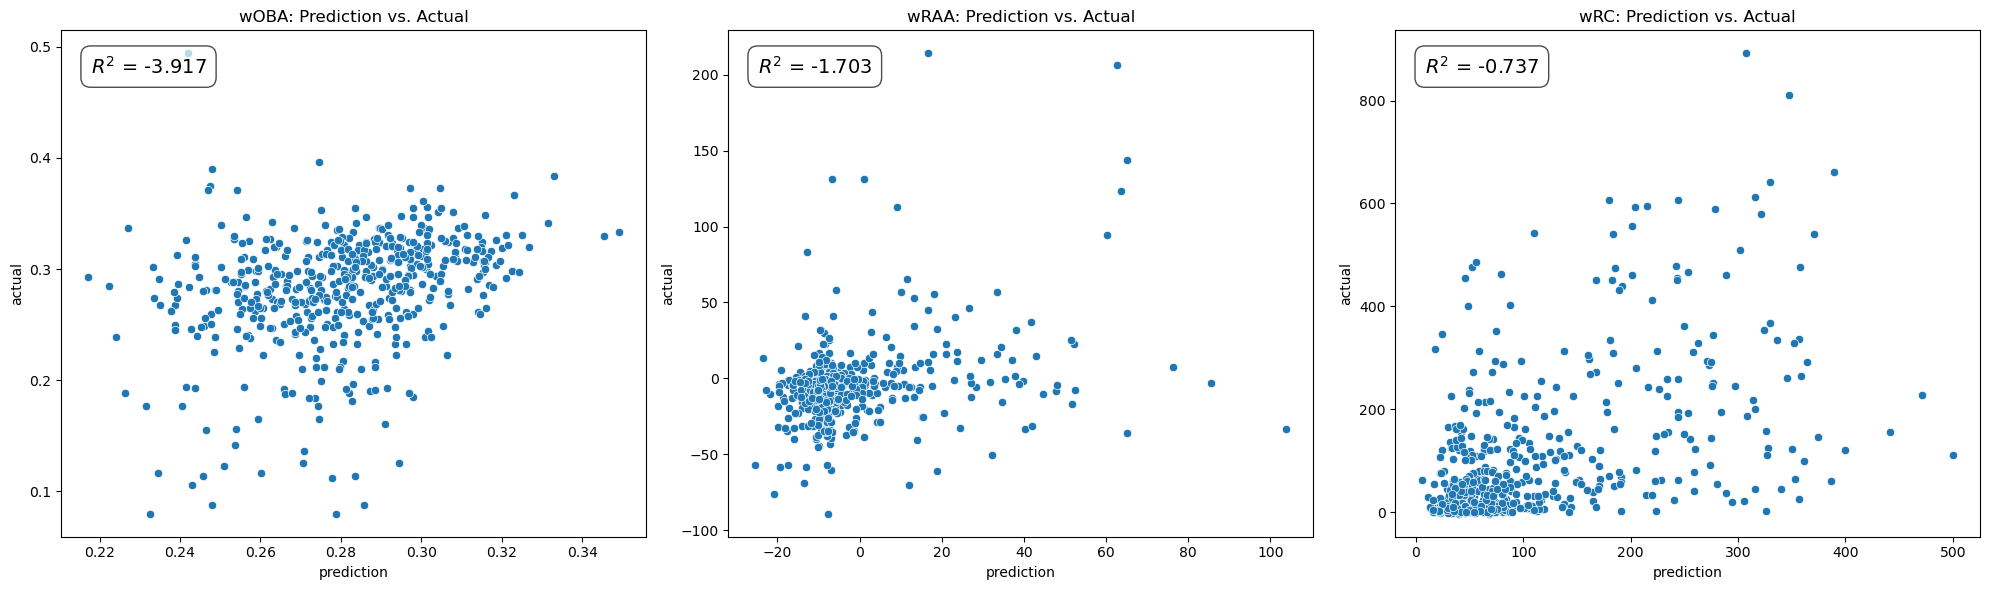

In [9]:
def lr_model(X: pd.DataFrame, y: pd.DataFrame) -> List:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    return pd.DataFrame({"prediction": preds, "actual": y_test.values})


def rf_model(X: pd.DataFrame, y: pd.DataFrame) -> List:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = RandomForestRegressor()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    return pd.DataFrame({"prediction": preds, "actual": y_test.values})


wOBA_preds = lr_model(X, mapped_players["major_wOBA"])
wRAA_preds = rf_model(X, mapped_players["major_wRAA"])
wRC_preds = rf_model(X, mapped_players["major_wRC"])

# Calculate R^2 values
wOBA_r2_score = r2_score(wOBA_preds["prediction"], wOBA_preds["actual"])
wRAA_r2_score = r2_score(wRAA_preds["prediction"], wRAA_preds["actual"])
wRC_r2_score = r2_score(wRC_preds["prediction"], wRC_preds["actual"])

# Define subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define annotation position
x_pos, y_pos = 0.05, 0.95

# --- 1. wOBA Plot ---
sns.scatterplot(data=wOBA_preds, x="prediction", y="actual", ax=axes[0])
axes[0].set_title("wOBA: Prediction vs. Actual")
axes[0].text(
    x_pos,
    y_pos,
    f"$R^2$ = {wOBA_r2_score:.3f}",
    transform=axes[0].transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7),
)

# --- 2. wRAA Plot ---
sns.scatterplot(data=wRAA_preds, x="prediction", y="actual", ax=axes[1])
axes[1].set_title("wRAA: Prediction vs. Actual")
axes[1].text(
    x_pos,
    y_pos,
    f"$R^2$ = {wRAA_r2_score:.3f}",
    transform=axes[1].transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7),
)

# --- 3. wRC Plot ---
sns.scatterplot(data=wRC_preds, x="prediction", y="actual", ax=axes[2])
axes[2].set_title("wRC: Prediction vs. Actual")
axes[2].text(
    x_pos,
    y_pos,
    f"$R^2$ = {wRC_r2_score:.3f}",
    transform=axes[2].transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7),
)

plt.tight_layout()
plt.show()

Notice that while the StatCast data still yields suboptimal results, it is already evident that it provides better predictive power compared to traditional batting data. In a near future improvement of this project, I will conduct a better data cleaning, feature engineering, and hyperparameter tuning to get the best model as possible. Better models could also be experimented with alongside better data on the players.